# DOE stage Analysis

## imports

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import uncertainties as unc
import glob,sys,os, scipy.stats as stats
from datetime import datetime, timedelta

## Read in Data

In [2]:
file_list = glob.glob('C:\\Users\\Jason.Bane\\Documents\\Nautilus\\DOE_stage\\code_trials\\data\\*li*test*.csv')

#resort the file list via the date in the filename
def extract_date(file_name):
    base_name = os.path.basename(file_name)
    #find and isolate the date part
    #assume filename format is something-like-20231015-0130.csv
    part_name = base_name.split('-')[0]  
    test_name = base_name.split('-')[1]  
    date_str = base_name.split('-')[2]  # assuming the date is the second part
    time_str = base_name.split('-')[3][0:3]  # assuming the time is the third part
    
    date_time_Str = date_str + "-"+ time_str

    return pd.to_datetime(date_time_Str, format='%Y%m%d-%H%M')
file_list.sort(key=extract_date)

print(f"Found {len(file_list)} files to process.")
full_data_list = []
for file in file_list:
    print(f"Loading {file}")


    if "20260209" in file:
        print(f"Skipping {file} due to known data issues.")
        continue
    

    skip_cycle = [-1]
    if "20260206" in file:
        skip_cycle = [1,2,3,4,5,6]
    if "20260102" in file:
        skip_cycle = [1,2]

    #check first line of file, if it has : in it, skip
    with open(file, 'r') as f:
        first_line = f.readline()
        if ':' in first_line:
                skip_line = 1
        else:
                skip_line = 0
            
    data = pd.read_csv(file, skiprows=skip_line)

    #switch the colmn names for  Bassler Fit Quality and Bassler Uncertainty
    data = data.rename(columns={'Bassler Fit Quality': 'Bassler Uncertainty_temp',
                                'Bassler Uncertainty': 'Bassler Fit Quality'})
    data['Bassler Uncertainty'] = data['Bassler Uncertainty_temp']
    data = data.drop(columns=['Bassler Uncertainty_temp'])

    # Clean up the cycle count. Average over duplicates cycle counts, for Linear stage state just say retracted  
    data = data.groupby('Cycle Number').agg({
        'Timestamp': 'first',
        'Linear Stage State': 'first',
        'Rotation Stage Angle': 'mean',
        'Bassler Angle': 'mean',
        'Bassler Fit Quality': 'mean',
        'Bassler Success': 'mean',
        'Bassler Uncertainty': 'mean'
    }).reset_index()

    #if the skip_cycle as non negative value, remove those cycle numbers from the data
    if skip_cycle[0] >= 0:
        data = data[~data['Cycle Number'].isin(skip_cycle)]

    #remove the cycle after a rotation change of 5 degrees or more
    rot_angles = data['Rotation Stage Angle'].values
    to_remove = []
    for i in range(1, len(rot_angles)):
        if abs(rot_angles[i] - rot_angles[i-1]) >= 5:
            to_remove.append(i)
    data = data.drop(data.index[to_remove]).reset_index(drop=True)

    full_data_list.append(data)
if len(full_data_list) > 0:
    full_data = pd.concat(full_data_list, ignore_index=True)
else:
    full_data = pd.DataFrame()
print("Data loading complete.")

#Use full_data to build a table of Daily Cycle Counts by date, plus a plot of Cycle Count vs Time
full_data['Date'] = pd.to_datetime(full_data['Timestamp'], format='%y/%m/%d %H:%M:%S.%f').dt.date  
#round all data to 3 points after the decimal
full_data['Rotation Stage Angle'] = full_data['Rotation Stage Angle'].round(2)
full_data['Bassler Angle']        = full_data['Bassler Angle'].round(2)
full_data['Bassler Fit Quality']  = full_data['Bassler Fit Quality'].round(2)
full_data['Bassler Uncertainty']  = full_data['Bassler Uncertainty'].round(2)    
cumulative_counts=[]
daily_counts= []
dates=[]
lastcount=0
for date in full_data['Date'].unique():
    daily_data = full_data[full_data['Date'] == date]
    cumulative_counts.append(len(daily_data) + lastcount)
    lastcount = len(daily_data) + lastcount
    dates.append(date)
    daily_counts.append(len(daily_data))


degtomrad = 17.453293 

Found 46 files to process.
Loading C:\Users\Jason.Bane\Documents\Nautilus\DOE_stage\code_trials\data\DOE-lifetest-20251202-1450.csv
Loading C:\Users\Jason.Bane\Documents\Nautilus\DOE_stage\code_trials\data\DOE-lifetest-20251203-1610.csv
Loading C:\Users\Jason.Bane\Documents\Nautilus\DOE_stage\code_trials\data\DOE-lifetest-20251208-1050.csv
Loading C:\Users\Jason.Bane\Documents\Nautilus\DOE_stage\code_trials\data\DOE-lifetest-20251208-1607.csv
Loading C:\Users\Jason.Bane\Documents\Nautilus\DOE_stage\code_trials\data\DOE-lifetest-20251209-1415.csv
Loading C:\Users\Jason.Bane\Documents\Nautilus\DOE_stage\code_trials\data\DOE-lifetest-20251212-1618.csv
Loading C:\Users\Jason.Bane\Documents\Nautilus\DOE_stage\code_trials\data\DOE-lifetest-20251217-1135.csv
Loading C:\Users\Jason.Bane\Documents\Nautilus\DOE_stage\code_trials\data\DOE-lifetest-20251217-1140.csv
Loading C:\Users\Jason.Bane\Documents\Nautilus\DOE_stage\code_trials\data\DOE-lifetest-20251222-0915.csv
Loading C:\Users\Jason.Bane\

In [3]:
full_data[-10:]

,Cycle Number,Timestamp,Linear Stage State,Rotation Stage Angle,Bassler Angle,Bassler Fit Quality,Bassler Success,Bassler Uncertainty,Date
1394845,66109,26/03/13 11:25:01.132,Retracted,-0.04,359.92,1.00,1.0,0.14,2026-03-13
1394846,66110,26/03/13 11:25:05.085,Retracted,-0.05,359.77,0.95,1.0,0.11,2026-03-13
1394847,66111,26/03/13 11:25:09.204,Retracted,-0.04,359.88,0.99,1.0,0.15,2026-03-13
1394848,66112,26/03/13 11:25:13.273,Retracted,-0.06,359.91,1.00,1.0,0.06,2026-03-13
1394849,66113,26/03/13 11:25:16.975,Retracted,-0.04,359.93,1.00,1.0,0.01,2026-03-13
1394850,66114,26/03/13 11:25:21.027,Retracted,-0.04,359.90,1.00,1.0,0.06,2026-03-13
1394851,66115,26/03/13 11:25:25.195,Retracted,-0.05,359.93,1.00,1.0,0.05,2026-03-13
1394852,66116,26/03/13 11:25:29.213,Retracted,-0.04,359.90,1.00,1.0,0.08,2026-03-13
1394853,66117,26/03/13 11:25:33.200,Retracted,-0.05,359.90,1.00,1.0,0.06,2026-03-13
1394854,66118,26/03/13 11:25:37.234,Retracted,-0.00,359.92,1.00,1.0,0.04,2026-03-13


## Cycles plot

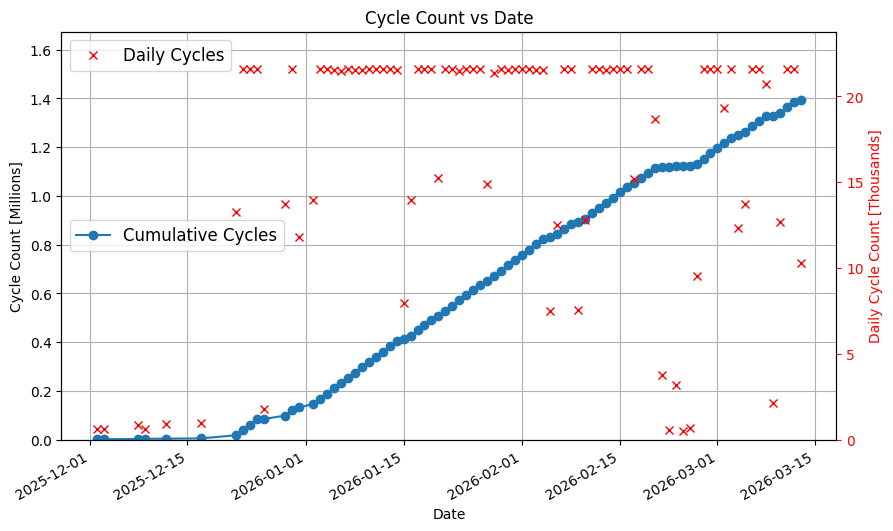

In [4]:
fig, ax = plt.subplots(figsize=(10,6))

#plot cumlative counts in millions

ax.plot(dates, np.array(cumulative_counts)/1e6, marker='o', linestyle='-', label='Cumulative Cycles')
#plot daily counts on a second axis on the same plot
ax2 = ax.twinx()
ax2.plot(dates, np.array(daily_counts)/1000, marker='x', color="red", linestyle=' ', label='Daily Cycles')
#color the second y axis ticks to match the line color
ax2.tick_params(axis='y', colors='red')
#color the second y axis label to match the line color
ax2.set_ylabel('Daily Cycle Count [Thousands]', color='red')

#determine the  of the max values to set the y limits
max_2 = max(daily_counts)
max_1 = max(cumulative_counts) 


ax2.set_ylim(-0.001, max(daily_counts)/1000*1.1)
ax.set_ylim(-0.0001, max(cumulative_counts)/1e6*1.2)
#format the y axis for ax2 to match the grid for ax



#format the x axis to show dates nicely
fig.autofmt_xdate()

ax.set_xlabel('Date')


ax.set_ylabel('Cycle Count [Millions]')
ax.set_title('Cycle Count vs Date')
ax.legend(loc = 'center left',fontsize='large')
ax2.legend(loc='upper left' ,fontsize='large')
ax.grid()

In [5]:
#get the current date and time




## Count and timing info

In [14]:
# when will we get a mil
from datetime import timedelta
from datetime import date, time
current_time = time()
i =-1
target_count = 1700000

l_int = -1
f_int = -4

Count_per_day = np.average(daily_counts[f_int:l_int])

print(f"Average Count per day over last {len(daily_counts[f_int:l_int])} days: {Count_per_day}")
print(f"Current cumulative count: {cumulative_counts[i]} on date {dates[i]}")

print(f"Projected date for {target_count} cycles:")

# use the data and time to determine the projected date after adding the timedelta
now = pd.to_datetime('now')
print( now + timedelta(days=((target_count - cumulative_counts[i])/Count_per_day)) )
print(f"\nTime till {target_count} cycles:")
print( timedelta(days=((target_count - cumulative_counts[i])/Count_per_day)) )


print(f"Days till {target_count} cycles:")
print((target_count - cumulative_counts[i])/Count_per_day)

Average Count per day over last 3 days: 18613.0
Current cumulative count: 1394855 on date 2026-03-13
Projected date for 1700000 cycles:
2026-03-29 21:03:20.185494

Time till 1700000 cycles:
16 days, 9:27:37.744587
Days till 1700000 cycles:
16.39418685864718


## others

### new Varible - angle from 0

In [15]:
# set new varible "angle abs" = to 360 - angle if angle > 180, else just equal to angle

full_data["angle abs"] = full_data["Bassler Angle"].apply(lambda x: 360 - x if x > 180 else x).round(3)
#setnew ccolumn "Stage from 0" to 360 - Rotation Stage Angle if Rotation Stage Angle >= 180, else just abs(Rotation Stage Angle)

full_data["Stage from 0"] = np.where(full_data["Rotation Stage Angle"] >= 180,
                                     360 - full_data["Rotation Stage Angle"],
                                     np.abs(full_data["Rotation Stage Angle"])).round(3)
full_data["Bassler from 0"] = np.where(full_data["Bassler Angle"] >= 180,
                                     360 - full_data["Bassler Angle"],
                                        np.abs(full_data["Bassler Angle"])).round(3)



Length of data after 2026-01-07: 1163338
Length of data plotted: 11531
Mean of points away from zero: 15.04+/-0.05, (262.5+/-0.9 rad)  
Mean of points near zero: 0.06+/-0.05, (1.0+/-0.8 rad)  


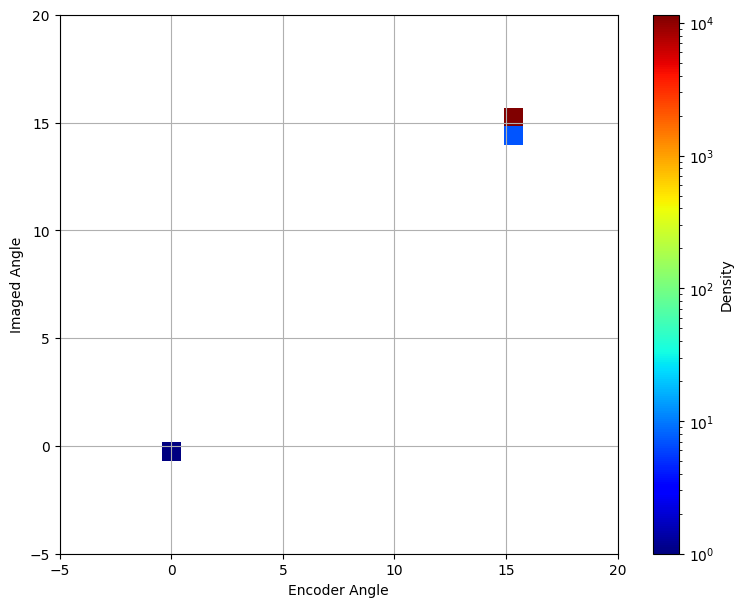

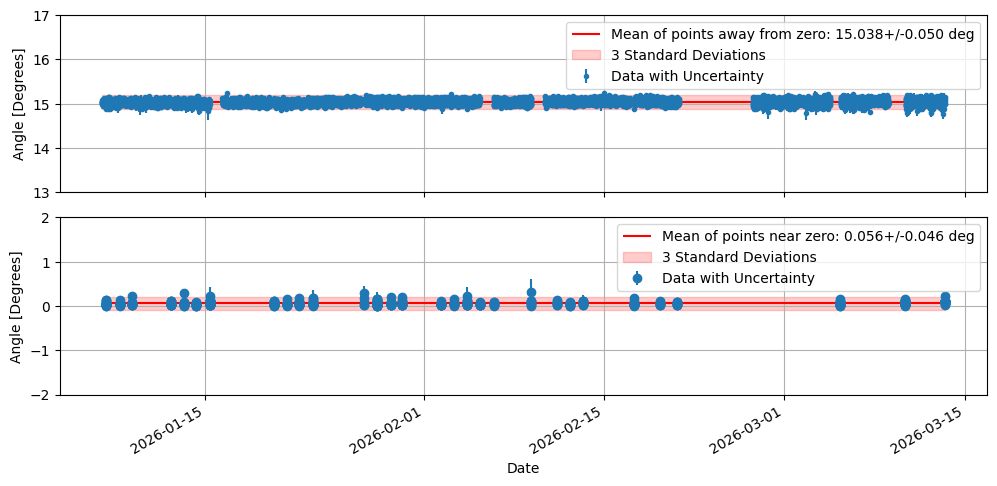

In [16]:
fig,ax = plt.subplots(1,1,figsize=(9,7))

starting_data = "2026-01-07"


past_date_data = full_data[pd.to_datetime(full_data['Timestamp'], format='%y/%m/%d %H:%M:%S.%f') > pd.to_datetime(starting_data)]

print(f"Length of data after {starting_data}: {len(past_date_data)}")

DF=past_date_data[(past_date_data['Bassler Success'] == 1) & (past_date_data["Bassler Uncertainty"]<1)][::100]
DF_zeros = past_date_data[(past_date_data['Bassler Success'] == 1) & (past_date_data["Bassler Uncertainty"]<3) & (past_date_data["Stage from 0"] <0.5) ]

print(f"Length of data plotted: {len(DF)}")
if len(DF) == 0:
    print("No data to plot after filtering for Bassler Success and Uncertainty.")
elif len(DF) >= 900000:
    print("Too much data to plot, consider filtering further.")

# plot counts of points with a colormap, where the color is determined by the density of points in that area

x = DF["Stage from 0"]
y = DF['Bassler from 0']
xy = np.vstack([x,y])

# #make a 2d histogram of the data to determine the density of points in each area
# hist, xedges, yedges = np.histogram2d(x, y, bins=30,range=[[-10,20],[-10,20]])
# xidx = np.clip(np.digitize(x, xedges) - 1, 0, hist.shape[0] - 1)
# yidx = np.clip(np.digitize(y, yedges) - 1, 0, hist.shape[1] - 1)
# z = hist[xidx, yidx]

# Use the returned image from hist2d for colorbar with log scale
from matplotlib.colors import LogNorm
h2d = ax.hist2d(x, y, bins=30, range=[[-5.5,20],[-5.85,20]], cmap='jet', norm=LogNorm())
plt.colorbar(h2d[3], ax=ax, label='Density')

#write the percentage of points in each bin







ax.set_xlim(-5,20)
ax.set_ylim(-5,20)

# sc = ax.scatter(x, y, c=z, s=50, edgecolor='red')
# plt.colorbar(sc, ax=ax, label='Density')
ax.set_xlabel('Encoder Angle')
ax.set_ylabel('Imaged Angle')

ax.grid()
# ax.errorbar(DF["Stage from 0"],xerr= 0.2, y=DF['Bassler from 0'], yerr=np.abs(DF['Bassler Uncertainty']), fmt='o', linestyle=' ')



fig,[ax,cx] = plt.subplots(2,1,figsize=(10,5), sharex=True,)



plt.tight_layout()
ax.errorbar(pd.to_datetime(DF["Timestamp"], format='%y/%m/%d %H:%M:%S.%f'), y=DF['Bassler from 0'], yerr=np.abs(DF['Bassler Uncertainty'])/5.0, fmt='.', linestyle=' ', label='Data with Uncertainty')
# bx.errorbar(pd.to_datetime(DF["Timestamp"], format='%y/%m/%d %H:%M:%S.%f'), y=DF['Bassler from 0'], yerr=np.abs(DF['Bassler Uncertainty']), fmt='o', linestyle=' ', label='Data with Uncertainty')
cx.errorbar(pd.to_datetime(DF_zeros["Timestamp"], format='%y/%m/%d %H:%M:%S.%f'), y=DF_zeros['Bassler from 0'], 
            yerr=np.abs(DF_zeros['Bassler Uncertainty'])/5, fmt='o', linestyle=' ', label='Data with Uncertainty')


Not_Zeros = DF[DF["Stage from 0"] > 0.5]
Not_zeros_mean = Not_Zeros["Bassler from 0"].mean()
Not_zeros_std = Not_Zeros["Bassler from 0"].std()
Not_zeros_mean_unc = unc.ufloat(Not_zeros_mean, Not_zeros_std)


ax.hlines(Not_zeros_mean, pd.to_datetime(DF["Timestamp"].min(), format='%y/%m/%d %H:%M:%S.%f'), pd.to_datetime(DF["Timestamp"].max(),
         format='%y/%m/%d %H:%M:%S.%f'), colors='red', label=f'Mean of points away from zero: {Not_zeros_mean_unc:.2u} deg'  )
ax.fill_betweenx([Not_zeros_mean - Not_zeros_std*3, Not_zeros_mean + Not_zeros_std*3], pd.to_datetime(DF["Timestamp"].min(), format='%y/%m/%d %H:%M:%S.%f'), pd.to_datetime(DF["Timestamp"].max(), format='%y/%m/%d %H:%M:%S.%f'), color='red', alpha=0.2, label='3 Standard Deviations')   

print(f"Mean of points away from zero: {Not_zeros_mean_unc}, ({Not_zeros_mean_unc*degtomrad} rad)  ")


zeros_mean = DF_zeros["Bassler from 0"].mean()
zeros_std = DF_zeros["Bassler from 0"].std()



zeros_mean_unc = unc.ufloat(zeros_mean, zeros_std)
cx.hlines(zeros_mean, pd.to_datetime(DF_zeros["Timestamp"].min(), format='%y/%m/%d %H:%M:%S.%f'), pd.to_datetime(DF_zeros["Timestamp"].max(), format='%y/%m/%d %H:%M:%S.%f'), colors='red', label=f'Mean of points near zero: {zeros_mean_unc:.2u} deg')
cx.fill_betweenx([zeros_mean - zeros_std*3, zeros_mean + zeros_std*3], pd.to_datetime(DF_zeros["Timestamp"].min(), format='%y/%m/%d %H:%M:%S.%f'), pd.to_datetime(DF_zeros["Timestamp"].max(), format='%y/%m/%d %H:%M:%S.%f'), color='red', alpha=0.2, label='3 Standard Deviations')    

print(f"Mean of points near zero: {zeros_mean_unc}, ({zeros_mean_unc*degtomrad} rad)  ")

#make the timestamp on the x axis look nice
fig.autofmt_xdate()

ax.set_ylabel('Angle [Degrees]')
cx.set_xlabel('Date')
ax.set_ylim(13,17)
ax.grid(True)
ax.legend()

cx.set_ylim(-2,2)
cx.set_ylabel('Angle [Degrees]')
cx.grid()
cx.legend()


In [17]:
0.25*degtomrad

4.36332325

Mean of points near zero with neg: -0.03+/-0.07, (-0.4+/-1.2 rad)  
Shapiro-Wilk test statistic: 0.9787, p-value: 0.0000
The data is not normally distributed (reject null hypothesis).
Mean of points near zero with neg: -0.03+/-0.07, (-0.4+/-1.2 rad)  


C:\Users\Jason.Bane\AppData\Local\Temp\ipykernel_6156\1336137535.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  DF_zeros['Angle_with_neg'] = round(DF_zeros.apply(lambda row: row['Bassler Angle'] if row['Bassler Angle'] <= 180 else row['Bassler Angle'] - 360, axis=1),2)


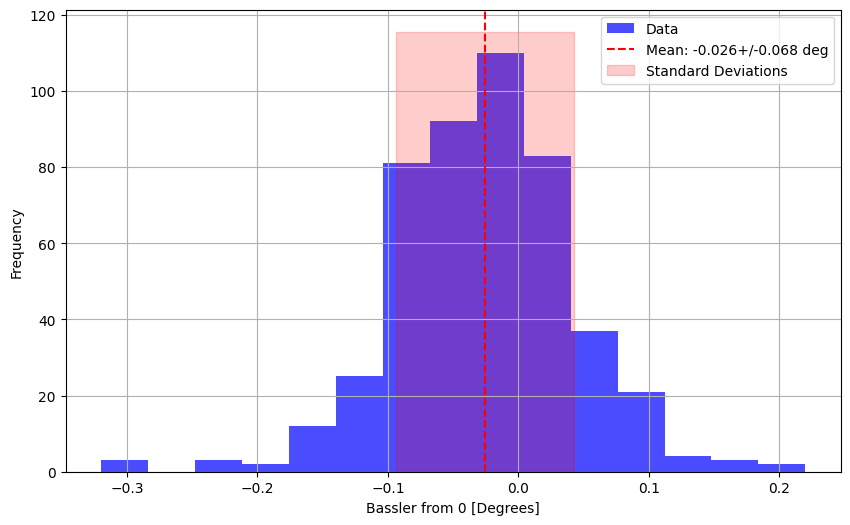

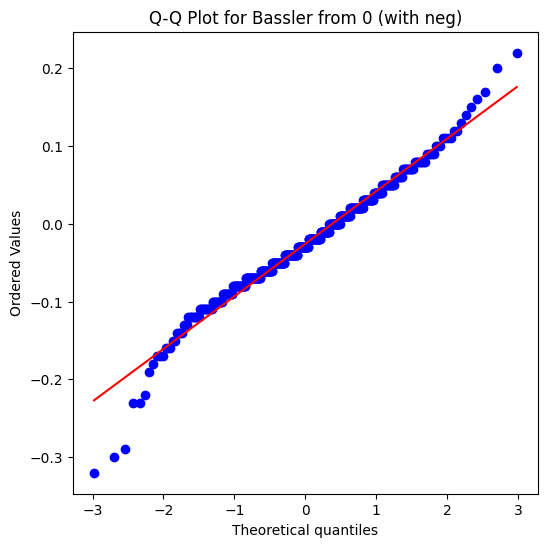

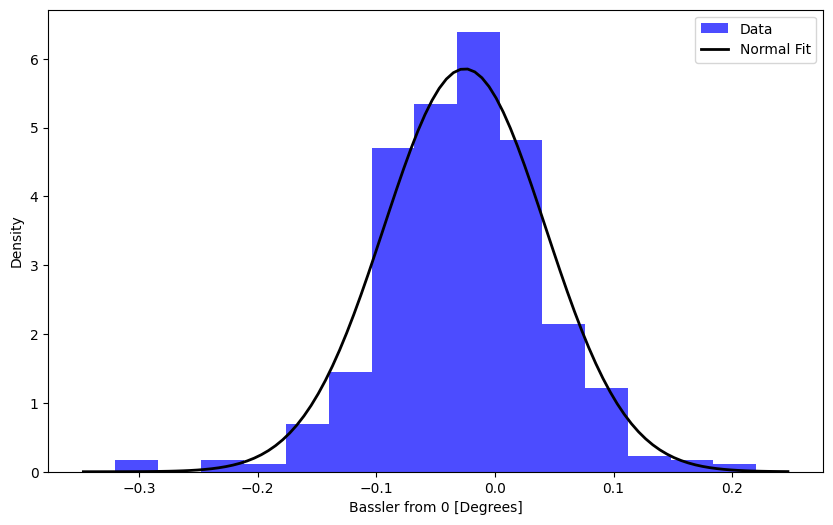

In [18]:
#from 0 including neg
DF_zeros['Angle_with_neg'] = round(DF_zeros.apply(lambda row: row['Bassler Angle'] if row['Bassler Angle'] <= 180 else row['Bassler Angle'] - 360, axis=1),2)


#histogram DF_zeros['Bassler from 0'] with 20 bins, and a vertical line at the mean, and shaded area for 3 standard deviations
fig, ax = plt.subplots(figsize=(10,6))
ax.hist(DF_zeros['Angle_with_neg'], bins=15, color='blue', alpha=0.7, label='Data')

mean = DF_zeros['Angle_with_neg'].mean()
std = DF_zeros['Angle_with_neg'].std()
mean_unc = unc.ufloat(mean, std)
print(f"Mean of points near zero with neg: {mean_unc}, ({mean_unc*degtomrad} rad)  ")

ax.axvline(mean, color='red', linestyle='--', label=f'Mean: {mean_unc:.2u} deg')
ax.fill_betweenx([0, ax.get_ylim()[1]], mean - std, mean + std, color='red', alpha=0.2, label='Standard Deviations')
ax.set_xlabel('Bassler from 0 [Degrees]')
ax.set_ylabel('Frequency')
ax.legend()
ax.grid(True)


#is the data normally distributed? Use a Q-Q plot to check
import scipy.stats as stats
fig, ax = plt.subplots(figsize=(6,6))
stats.probplot(DF_zeros['Angle_with_neg'], dist="norm", plot=ax)
ax.set_title('Q-Q Plot for Bassler from 0 (with neg)') 

#perform a Shapiro-Wilk test for normality
shapiro_stat, shapiro_p = stats.shapiro(DF_zeros['Angle_with_neg'])
print(f"Shapiro-Wilk test statistic: {shapiro_stat:.4f}, p-value: {shapiro_p:.4f}")
if shapiro_p > 0.05:
    print("The data is likely normally distributed (fail to reject null hypothesis).")  
else:
    print("The data is not normally distributed (reject null hypothesis).")


#plot a histogram of the data with a normal distribution fit overlaid
fig, ax = plt.subplots(figsize=(10,6))
ax.hist(DF_zeros['Angle_with_neg'], bins=15, color='blue', alpha=0.7, label='Data', density=True)
mean = DF_zeros['Angle_with_neg'].mean()
std = DF_zeros['Angle_with_neg'].std()
mean_unc = unc.ufloat(mean, std)
print(f"Mean of points near zero with neg: {mean_unc}, ({mean_unc*degtomrad} rad)  ")
xmin, xmax = ax.get_xlim()
x = np.linspace(xmin, xmax, 100)
p = stats.norm.pdf(x, mean, std)
ax.plot(x, p, 'k', linewidth=2, label='Normal Fit')
ax.set_xlabel('Bassler from 0 [Degrees]')
ax.set_ylabel('Density')
ax.legend()





Mean of points away from zero: 15.04+/-0.05, (262.5+/-0.9 rad)  
Shapiro-Wilk test statistic: 0.9938, p-value: 0.000000
The data is likely not normally distributed (reject null hypothesis).
Mann-Whitney U test statistic: 0.0000, p-value: 0.000000
The distributions of points near zero and away from zero are likely different (reject null hypothesis).
Mean of points away from zero: 15.04+/-0.05, (262.5+/-0.9 rad)  


C:\Users\Jason.Bane\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\scipy\stats\_axis_nan_policy.py:579: UserWarning: scipy.stats.shapiro: For N > 5000, computed p-value may not be accurate. Current N is 11530.
  res = hypotest_fun_out(*samples, **kwds)


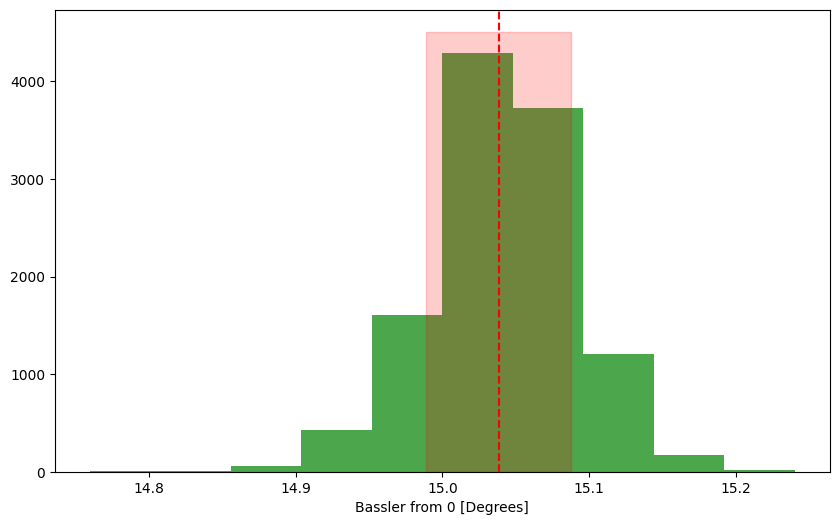

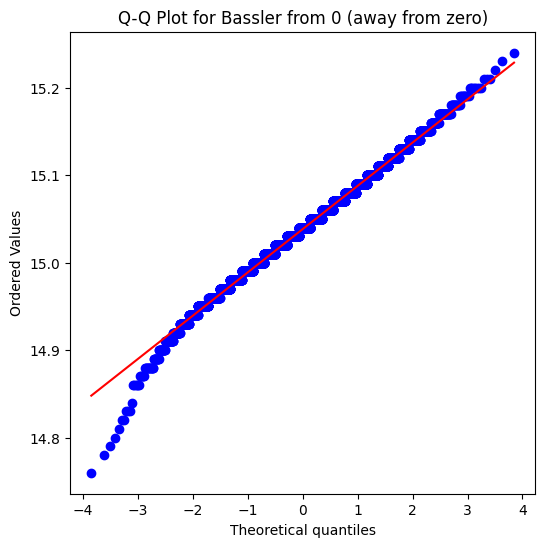

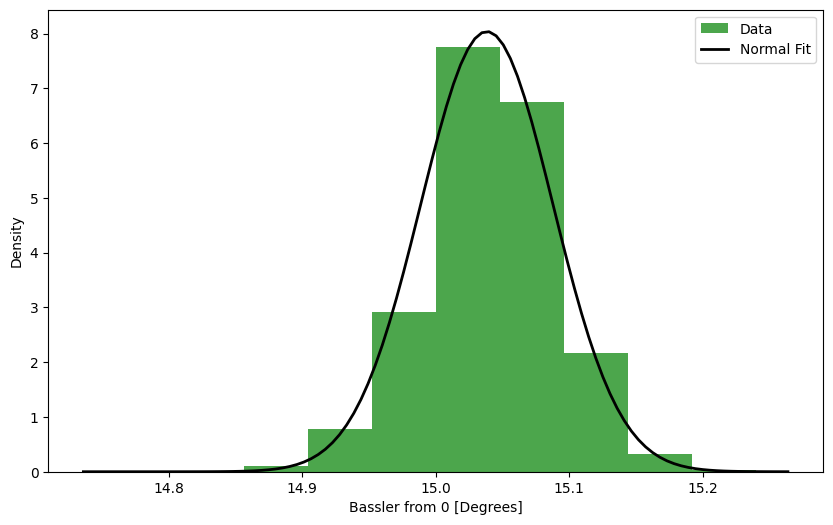

In [19]:
#histogram of non zero points
fig, ax = plt.subplots(figsize=(10,6))
ax.hist(Not_Zeros['Bassler from 0'], bins=10, color='green', alpha=0.7, label='Data')
mean = Not_Zeros['Bassler from 0'].mean()   
std = Not_Zeros['Bassler from 0'].std()
mean_unc = unc.ufloat(mean, std)
print(f"Mean of points away from zero: {mean_unc}, ({mean_unc*degtomrad} rad)  ")
ax.axvline(mean, color='red', linestyle='--', label=f'Mean:{mean_unc:.2u} deg')
ax.fill_betweenx([0, ax.get_ylim()[1]], mean - std, mean + std, color='red', alpha=0.2, label='Standard Deviations')
ax.set_xlabel('Bassler from 0 [Degrees]')


#is the data normally distributed? Use a Q-Q plot to check
fig, ax = plt.subplots(figsize=(6,6))
stats.probplot(Not_Zeros['Bassler from 0'], dist="norm", plot=ax)
ax.set_title('Q-Q Plot for Bassler from 0 (away from zero)')

#quanitatively check normality with a Shapiro-Wilk test
shapiro_stat, shapiro_p = stats.shapiro(Not_Zeros['Bassler from 0'])
print(f"Shapiro-Wilk test statistic: {shapiro_stat:.4f}, p-value: {shapiro_p:.6f}")
if shapiro_p > 0.05:
    print("The data is likely normally distributed (fail to reject null hypothesis).")
else:
    print("The data is likely not normally distributed (reject null hypothesis).")

# pefrome a Mann-Whitney U test to compare the distribution of points near zero and away from zero
u_stat, u_p = stats.mannwhitneyu(DF_zeros['Angle_with_neg'], Not_Zeros['Bassler from 0'], alternative='two-sided')
print(f"Mann-Whitney U test statistic: {u_stat:.4f}, p-value: {u_p:.6f}")
if u_p > 0.05:
    print("The distributions of points near zero and away from zero are likely the same (fail to reject null hypothesis).") 
else:
    print("The distributions of points near zero and away from zero are likely different (reject null hypothesis).")








#plot a histogram of the data with a normal distribution fit overlaid
fig, ax = plt.subplots(figsize=(10,6))
ax.hist(Not_Zeros['Bassler from 0'], bins=10, color='green', alpha=0.7, label='Data', density=True)
mean = Not_Zeros['Bassler from 0'].mean()
std = Not_Zeros['Bassler from 0'].std()
mean_unc = unc.ufloat(mean, std)
print(f"Mean of points away from zero: {mean_unc}, ({mean_unc*degtomrad} rad)  ")
xmin, xmax = ax.get_xlim()
x = np.linspace(xmin, xmax, 100)
p = stats.norm.pdf(x, mean, std)
ax.plot(x, p, 'k', linewidth=2, label='Normal Fit')
ax.set_xlabel('Bassler from 0 [Degrees]')
ax.set_ylabel('Density')
ax.legend()

In [20]:
#make a cute to look at the bad groups. look at points when the two angles are not close

DF_bad = DF[ np.abs(DF['Stage from 0'] - DF['Bassler from 0'])>1]

DF_bad



,Cycle Number,Timestamp,Linear Stage State,Rotation Stage Angle,Bassler Angle,Bassler Fit Quality,Bassler Success,Bassler Uncertainty,Date,angle abs,Stage from 0,Bassler from 0


In [21]:

DF[DF["Date"] == datetime.strptime("2026-02-06", "%Y-%m-%d").date()]

,Cycle Number,Timestamp,Linear Stage State,Rotation Stage Angle,Bassler Angle,Bassler Fit Quality,Bassler Success,Bassler Uncertainty,Date,angle abs,Stage from 0,Bassler from 0
830144,45,26/02/06 10:08:44.007,Retracted,14.99,15.08,1.0,1.0,0.13,2026-02-06,15.08,14.99,15.08
830244,145,26/02/06 10:15:24.076,Retracted,14.98,15.00,1.0,1.0,0.10,2026-02-06,15.00,14.98,15.00
830344,245,26/02/06 10:22:03.911,Retracted,14.98,15.06,1.0,1.0,0.04,2026-02-06,15.06,14.98,15.06
830444,345,26/02/06 10:28:43.980,Retracted,14.98,15.06,1.0,1.0,0.12,2026-02-06,15.06,14.98,15.06
830544,445,26/02/06 10:35:23.818,Retracted,14.98,14.95,1.0,1.0,0.34,2026-02-06,14.95,14.98,14.95
...,...,...,...,...,...,...,...,...,...,...,...,...
842145,12046,26/02/06 23:28:47.900,Retracted,14.98,15.01,1.0,1.0,0.08,2026-02-06,15.01,14.98,15.01
842245,12146,26/02/06 23:35:27.836,Retracted,14.98,15.04,1.0,1.0,0.07,2026-02-06,15.04,14.98,15.04
842345,12246,26/02/06 23:42:08.072,Retracted,14.98,15.00,1.0,1.0,0.02,2026-02-06,15.00,14.98,15.00
842445,12346,26/02/06 23:48:48.022,Retracted,14.99,15.11,1.0,1.0,0.13,2026-02-06,15.11,14.99,15.11


Text(0, 0.5, 'Bassler Angle (degrees)')

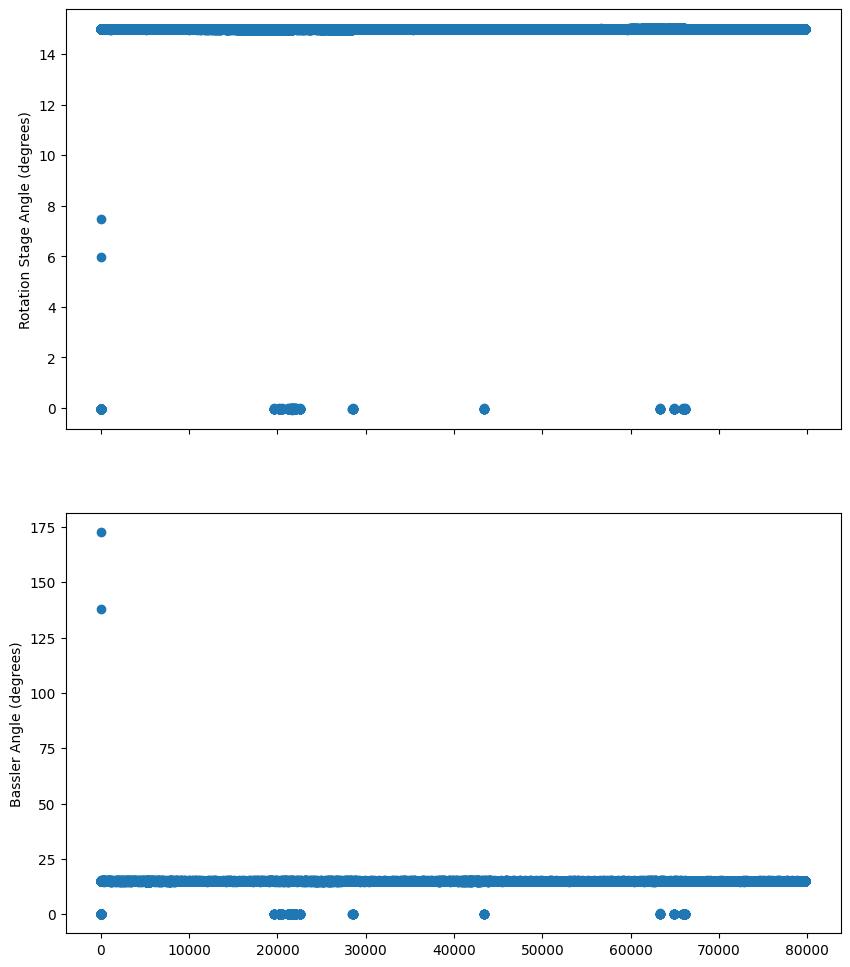

In [22]:
#for data after 01/01/2026 and for succesful fits , plot angle info vs cycle count

date_cut = '2026-01-10'
fig,ax = plt.subplots(2,1,figsize=(10,12),sharex=True)
post_data = full_data[(pd.to_datetime(full_data['Timestamp'], format='%y/%m/%d %H:%M:%S.%f') >= pd.to_datetime(date_cut)) & (full_data['Bassler Success'] == 1)]
ax[0].plot(post_data['Cycle Number'], post_data['Rotation Stage Angle'], marker='o', linestyle=' ')
ax[0].set_ylabel('Rotation Stage Angle (degrees)') 

ax[1].plot(post_data['Cycle Number'], post_data['angle abs'], marker='o', linestyle=' ')
ax[1].set_ylabel('Bassler Angle (degrees)')


Text(0, 0.5, 'Bassler Angle (degrees)')

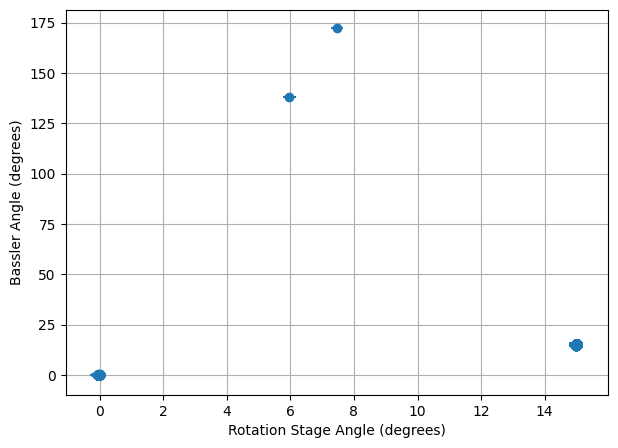

In [23]:
fig,ax = plt.subplots(1,1,figsize=(7,5))

date_cut = '2026-01-15'

post_data = full_data[(pd.to_datetime(full_data['Timestamp'], format='%y/%m/%d %H:%M:%S.%f') >= pd.to_datetime(date_cut)) & (full_data['Bassler Success'] == 1)]

good_data = post_data[(post_data['Bassler Success'] == 1) & (post_data['Bassler Uncertainty'] < 2)]


ax.errorbar(good_data["Rotation Stage Angle"],xerr= 0.2, y=good_data['angle abs'], yerr=np.abs(good_data['Bassler Uncertainty']), fmt='o', linestyle=' ')
ax.grid()
ax.set_xlabel('Rotation Stage Angle (degrees)')
ax.set_ylabel('Bassler Angle (degrees)')

Text(0, 0.5, 'Absolute Angle Difference (degrees)')

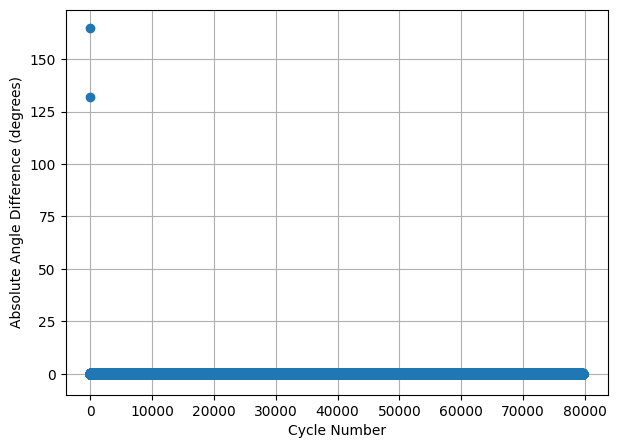

In [24]:
fig,ax = plt.subplots(1,1,figsize=(7,5))

ax.errorbar(good_data["Cycle Number"],xerr= 0.2, y=np.abs(good_data['angle abs']-good_data['Rotation Stage Angle']), yerr=np.abs(good_data['Bassler Uncertainty']), fmt='o', linestyle=' ')

# add a second x axis for date
# ax2 = ax.twiny()
# ax2.set_xlim(ax.get_xlim())
# ax2.set_xticks(good_data["Cycle Number"])
# ax2.set_xticklabels(good_data['Date'], rotation=45, ha='right')
# ax2.set_xlabel('Date')

ax.grid()
ax.set_xlabel('Cycle Number')
ax.set_ylabel('Absolute Angle Difference (degrees)')

In [25]:
good_data[(good_data['Rotation Stage Angle'] <6) & (good_data['angle abs'] >6) ]

,Cycle Number,Timestamp,Linear Stage State,Rotation Stage Angle,Bassler Angle,Bassler Fit Quality,Bassler Success,Bassler Uncertainty,Date,angle abs,Stage from 0,Bassler from 0
636489,3,26/01/27 08:38:49.597,Retracted,5.97,221.98,1.0,1.0,0.09,2026-01-27,138.02,5.97,138.02


In [26]:
len(good_data)

980688

In [27]:
#setnew ccolumn "Stage from 0" to 360 - Rotation Stage Angle if Rotation Stage Angle >= 180, else just abs(Rotation Stage Angle)

full_data["Stage from 0"] = np.where(full_data["Rotation Stage Angle"] >= 180,
                                     360 - full_data["Rotation Stage Angle"],
                                     np.abs(full_data["Rotation Stage Angle"]))
full_data["Bassler from 0"] = np.where(full_data["Bassler Angle"] >= 180,
                                     360 - full_data["Bassler Angle"],
                                        np.abs(full_data["Bassler Angle"]))








In [28]:
full_data

,Cycle Number,Timestamp,Linear Stage State,Rotation Stage Angle,Bassler Angle,Bassler Fit Quality,Bassler Success,Bassler Uncertainty,Date,angle abs,Stage from 0,Bassler from 0
0,0,25/12/02 14:49:49.958,Retracted,0.26,0.00,0.00,0.0,0.00,2025-12-02,0.00,0.26,0.00
1,1,25/12/02 14:49:50.641,Retracted,0.04,193.26,0.20,0.0,0.09,2025-12-02,166.74,0.04,166.74
2,2,25/12/02 14:49:54.644,Retracted,0.04,193.56,0.88,1.0,1.03,2025-12-02,166.44,0.04,166.44
3,3,25/12/02 14:49:58.612,Retracted,0.04,193.17,1.00,1.0,0.90,2025-12-02,166.83,0.04,166.83
4,4,25/12/02 14:50:02.698,Retracted,0.04,193.39,0.81,1.0,0.13,2025-12-02,166.61,0.04,166.61
...,...,...,...,...,...,...,...,...,...,...,...,...
1394850,66114,26/03/13 11:25:21.027,Retracted,-0.04,359.90,1.00,1.0,0.06,2026-03-13,0.10,0.04,0.10
1394851,66115,26/03/13 11:25:25.195,Retracted,-0.05,359.93,1.00,1.0,0.05,2026-03-13,0.07,0.05,0.07
1394852,66116,26/03/13 11:25:29.213,Retracted,-0.04,359.90,1.00,1.0,0.08,2026-03-13,0.10,0.04,0.10
1394853,66117,26/03/13 11:25:33.200,Retracted,-0.05,359.90,1.00,1.0,0.06,2026-03-13,0.10,0.05,0.10


In [29]:
24*60*60/21000

4.114285714285714